# Data preprocessing📑

In [ ]:
import pandas as pd
import scipy.stats
import numpy as np
import seaborn as sas
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter
import re

!pip install emoji
import emoji




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.2 MB/s eta 0:00:00


In [ ]:
df= pd.read_csv("sentimentdatasett.csv")
#Text Before The pre-processing
print(df[['Text']].head(20))

                                                 Text
0    Enjoying a beautiful day at the park!        ...
1    Traffic was terrible this morning.           ...
2    Just finished an amazing workout! 💪          ...
3    Excited about the upcoming weekend getaway!  ...
4    Trying out a new recipe for dinner tonight.  ...
5    Feeling grateful for the little things in lif...
6    Rainy days call for cozy blankets and hot coc...
7    The new movie release is a must-watch!       ...
8    Political discussions heating up on the timel...
9    Missing summer vibes and beach days.         ...
10   Just published a new blog post. Check it out!...
11   Feeling a bit under the weather today.       ...
12   Exploring the city's hidden gems.            ...
13   New year, new fitness goals! 💪               ...
14   Technology is changing the way we live.      ...
15   Reflecting on the past and looking ahead.    ...
16   Just adopted a cute furry friend! 🐾          ...
17   Late-night gaming sessi

In [ ]:
#Data Preprocessing: remove duplicate text
row = df.shape[0]
print('number of row before removeing the duplicates',row)
df = df.drop_duplicates(subset=['Text'])

rown = df.shape[0]
print('number of row after removeing the duplicates',rown , " \n ")

number of row before removeing the duplicates 732
number of row after removeing the duplicates 707  
 


In [ ]:
#Data Preprocessing: lower casing the text
df['Text'] = df['Text'].str.lower()
print(df[['Text']].head(20))

                                                 Text
0    enjoying a beautiful day at the park!        ...
1    traffic was terrible this morning.           ...
2    just finished an amazing workout! 💪          ...
3    excited about the upcoming weekend getaway!  ...
4    trying out a new recipe for dinner tonight.  ...
5    feeling grateful for the little things in lif...
6    rainy days call for cozy blankets and hot coc...
7    the new movie release is a must-watch!       ...
8    political discussions heating up on the timel...
9    missing summer vibes and beach days.         ...
10   just published a new blog post. check it out!...
11   feeling a bit under the weather today.       ...
12   exploring the city's hidden gems.            ...
13   new year, new fitness goals! 💪               ...
14   technology is changing the way we live.      ...
15   reflecting on the past and looking ahead.    ...
16   just adopted a cute furry friend! 🐾          ...
17   late-night gaming sessi

In [ ]:
#Data Preprocessing: removing stop words (ex: 'a', 'is' ,'of'....etc)
nltk.download('stopwords')
stopWords=set(stopwords.words('english'))
Text=df['Text']

def remove_stopword(x):
    #Divide The Text Into Words And Remove Common Word
    return ([word for word in str(x).split()if word not in stopWords])
    #Apply The Function To Row Element In The Text Column
Text=Text.apply(lambda x: remove_stopword(x))
print(Text , "\n \n")

0                      [enjoying, beautiful, day, park!]
1                          [traffic, terrible, morning.]
2                       [finished, amazing, workout!, 💪]
3                 [excited, upcoming, weekend, getaway!]
4                [trying, new, recipe, dinner, tonight.]
                             ...                        
727    [collaborating, science, project, received, re...
728    [attending, surprise, birthday, party, organiz...
729    [successfully, fundraising, school, charity, i...
730    [participating, multicultural, festival,, cele...
731    [organizing, virtual, talent, show, challengin...
Name: Text, Length: 707, dtype: object 
 



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#Data Preprocessing: Removing Punctuation (ex: '?' , '!' ...etc)
# & Special Characters (ex: '^' , '@' ...etc) And any Addtional non-impactful Spaces
var = df['Text']
df['Text'] = df['Text'].apply(lambda var:re.sub(r'[^\w\r ]+','',var))
df['Text'] = df['Text'].apply(lambda var:var.strip())

print(df[['Text']].head(20))

                                                Text
0               enjoying a beautiful day at the park
1                  traffic was terrible this morning
2                   just finished an amazing workout
3         excited about the upcoming weekend getaway
4         trying out a new recipe for dinner tonight
5     feeling grateful for the little things in life
6    rainy days call for cozy blankets and hot cocoa
7               the new movie release is a mustwatch
8   political discussions heating up on the timeline
9                missing summer vibes and beach days
10       just published a new blog post check it out
11             feeling a bit under the weather today
12                   exploring the citys hidden gems
13                        new year new fitness goals
14            technology is changing the way we live
15          reflecting on the past and looking ahead
16                  just adopted a cute furry friend
17             latenight gaming session with f

In [ ]:
#Conversion Of Emojis To words (' 😁 = Happy ', ' 😔 = Sad '.....etc)
def convert_emojis_to_text(Text):
    if isinstance(Text, str):
        return emoji.demojize(Text, delimiters=(" ", " "))
    return Text

df['Text'] = df['Text'].apply(convert_emojis_to_text)
print(df[['Text']].head(20))


                                                Text
0               enjoying a beautiful day at the park
1                  traffic was terrible this morning
2                   just finished an amazing workout
3         excited about the upcoming weekend getaway
4         trying out a new recipe for dinner tonight
5     feeling grateful for the little things in life
6    rainy days call for cozy blankets and hot cocoa
7               the new movie release is a mustwatch
8   political discussions heating up on the timeline
9                missing summer vibes and beach days
10       just published a new blog post check it out
11             feeling a bit under the weather today
12                   exploring the citys hidden gems
13                        new year new fitness goals
14            technology is changing the way we live
15          reflecting on the past and looking ahead
16                  just adopted a cute furry friend
17             latenight gaming session with f

In [ ]:
#Text After The pre-processing

print(df[['Text']].head(20))

                                                Text
0               enjoying a beautiful day at the park
1                  traffic was terrible this morning
2                   just finished an amazing workout
3         excited about the upcoming weekend getaway
4         trying out a new recipe for dinner tonight
5     feeling grateful for the little things in life
6    rainy days call for cozy blankets and hot cocoa
7               the new movie release is a mustwatch
8   political discussions heating up on the timeline
9                missing summer vibes and beach days
10       just published a new blog post check it out
11             feeling a bit under the weather today
12                   exploring the citys hidden gems
13                        new year new fitness goals
14            technology is changing the way we live
15          reflecting on the past and looking ahead
16                  just adopted a cute furry friend
17             latenight gaming session with f

In [ ]:
#Saving The Changes On df To a The Original csv File
df.to_csv("sentimentdatasetco.csv", index=False)

# Data Analysis📊


 relation between dayPart and Sentiment its correlated 
the p-value is 1.0623198213413997e-12 and hence we reject  the null hpothesis with 831 dgree of freedom 	  
	
relation between Seasons and Sentimentits correlated 
the p-value is 1.4961738062886681e-15 and hence we reject  the null hpothesis with 554 dgree of freedom 	  
	
relation between monthlpart and Sentimentits not-correlated  
the p-value is 0.15926984304919103 and hence we accept  the null hpothesis with 554 dgree of freedom 	  
	


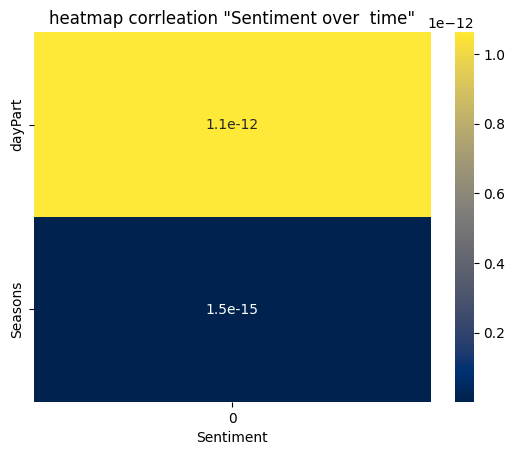

In [ ]:
#Data Analysis: the correlation of categoral data
df['dayPart'] = None
df['Seasons'] = None
df['monthlpart'] = None

df.loc[(5<df['Hour'] ) & (df['Hour']<12 ) ,'dayPart'] = 'Morning'
df.loc[(12<=df['Hour']) & (df['Hour']<=18),'dayPart'] = 'Afternoon'
df.loc[(18 < df['Hour'] ) &(df['Hour']<=23) ,'dayPart'] = 'nights'
df.loc[df['Hour']<=5 ,'dayPart'] = 'Late nights'

df.loc[(12 == df['Month'] ) &(df['Month'] <=2) ,'Seasons'] = 'Winter'
df.loc[( 3 <= df['Month'] ) &(df['Month'] ) <=5 ,'Seasons'] = 'Spring'
df.loc[(6 <= df['Month'] ) &(df['Month'] <= 8) ,'Seasons'] = 'Summer'
df.loc[(9 <= df['Month'] ) &(df['Month'] <=11) ,'Seasons'] = 'Autumn'

df.loc[(1 <= df['Day'] ) &(df['Day'] <=7) ,'monthlpart'] = 'First week'
df.loc[( 8 <= df['Day'] ) &(df['Day'] ) <=14 ,'monthlpart'] = 'Second week'
df.loc[(15 <= df['Day'] ) &(df['Day'] <= 21) ,'monthlpart'] = 'Third week'
df.loc[(22 <= df['Day'] ) &(df['Day'] <=28) ,'monthlpart'] = ' Fourth week'


def correlatedxy(x,y):
  Fcategoral=pd.crosstab(index=df[x],columns = df[y])
  chir =  scipy.stats.chi2_contingency(Fcategoral)
  p_value = chir[1]
  row = Fcategoral.shape[0]
  col = Fcategoral.shape[1]
  if chir[1]< 0.05:
    result = 'reject'
  else :
    result = 'accept'
  if p_value < 0.05:
    print("its correlated ")
  else:
    print("its not-correlated  ")
  degree_freedom = (row -1 )*(col-1)
  print(f"the p-value is {p_value} and hence we {result}  the null hpothesis with {degree_freedom} dgree of freedom \t  ")

  return "\t"
  #p-value for heatmap of categoral data by Lara
def correlatedHeatmap(x,y):
  Fcategoral=pd.crosstab(index=df[x],columns = df[y])
  chir =  scipy.stats.chi2_contingency(Fcategoral)
  p_value = chir[1]
  return p_value
  # visualization correlation of categoral by Lara
def heatmapcorr():
  listp = []
  row_lables=[]
  day_heat = correlatedHeatmap('dayPart', 'Sentiment')
  seasons_heat = correlatedHeatmap('Seasons', 'Sentiment')
  month_heat = correlatedHeatmap('monthlpart', 'Sentiment')
  if day_heat  < 0.05:
    listp.append(day_heat)
    row_lables.append('dayPart')

  if seasons_heat < 0.05:
    listp.append(seasons_heat)
    row_lables.append('Seasons')

  if month_heat < 0.05:
    listp.append(month_heat)
    row_lables.append('monthlpart')

  dfHeatmap = pd.DataFrame(listp)
  sas.heatmap(dfHeatmap, annot=True,cmap='cividis' , yticklabels=row_lables)
  plt.xlabel('Sentiment')
  plt.title('heatmap corrleation "Sentiment over  time"')
  plt.show()

print('\n relation between dayPart and Sentiment ' , end="")
print(correlatedxy('dayPart', 'Sentiment'))
print('relation between Seasons and Sentiment' , end="")
print(correlatedxy('Seasons', 'Sentiment'))
print('relation between monthlpart and Sentiment'  , end="")
print(correlatedxy('monthlpart', 'Sentiment'))
heatmapcorr()

In [ ]:
#Data Analysis: Word Frequency; to find the most common words for each sentiment
flattenedWords = []
for sublist in Text :
   for Word in sublist:
     flattenedWords.append(Word)

#Using The Counter Function To Count The Number Of Words
count=Counter(flattenedWords)
print(count)

Counter({'new': 43, 'feeling': 26, 'like': 26, 'beauty': 20, 'every': 19, 'exploring': 17, 'art': 17, 'lost': 17, 'day': 16, 'journey': 16, 'personal': 15, 'sense': 15, 'laughter': 15, "life's": 15, 'echoes': 15, 'symphony': 15, 'heart': 15, 'dance': 14, 'challenging': 13, 'surprise': 13, 'old': 13, 'embracing': 13, 'serenity': 13, 'whispers': 13, 'shattered': 13, 'world': 12, 'garden': 12, 'finding': 12, 'excitement': 12, 'moment': 12, 'joy': 12, 'ancient': 12, 'concert,': 12, 'dreams': 11, 'tales': 11, 'creating': 11, 'upcoming': 10, 'quiet': 10, 'love': 10, 'night': 10, 'school': 10, 'reflecting': 9, 'attending': 9, 'learning': 9, 'local': 9, 'experiencing': 9, 'gratitude': 9, 'silent': 9, 'life': 9, 'embarking': 9, 'moments': 9, 'time.': 9, 'labyrinth': 9, 'dancing': 9, 'soul': 9, 'painting': 8, 'project': 8, 'family': 8, 'music': 8, 'nature': 8, 'tears': 8, 'hopeful': 8, 'warmth': 8, 'challenges': 8, 'emotions': 8, 'nostalgia': 8, 'colors': 8, 'sky': 8, 'vibrant': 8, 'spent': 8, '

In [ ]:
#Data Analysis: Thematic analysis, to identify the main topics
# Define themes with associated keywords
themes = {
    'Good Vibes': [
        'happy', 'good', 'excellent','heart' ,'love', 'joy', 'amazing',
        'satisfied', 'great','relax' ,'laughter', 'wonderful', 'fantastic',
        'delighted', 'pleased', 'excited', 'cheerful','best','grateful'
    ],
    'Bad Vibes': [
        'angry', 'sad', 'bad', 'hate', 'disappointed', 'poor',
        'worst', 'frustrated', 'upset', 'terrible', 'awful',
        'horrible', 'displeased', 'dismayed', 'annoyed','unhappy'
    ],
    'Neutral vibes': [
        'okay', 'fine', 'average' ,'neutral', 'meh'
      , 'normal','ordinary',
        'mediocre', 'indifferent', 'fair', 'so-so'
    ]
}


# Function to classify text into themes
def classify_theme(Text):
    for theme, keywords in themes.items():
        if any(keyword in Text.lower() for keyword in keywords):
            return theme
    return 'unclassified'

df['Theme'] = df['Text'].apply(classify_theme)
df.head(20)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,dayPart,Seasons,monthlpart,Theme
0,0,0,enjoying a beautiful day at the park,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,Afternoon,Spring,Third week,Good Vibes
1,1,1,traffic was terrible this morning,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,Morning,Spring,Third week,Bad Vibes
2,2,2,just finished an amazing workout,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,Afternoon,Spring,Third week,Good Vibes
3,3,3,excited about the upcoming weekend getaway,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,Afternoon,Spring,Third week,Good Vibes
4,4,4,trying out a new recipe for dinner tonight,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,nights,Spring,Third week,unclassified
5,5,5,feeling grateful for the little things in life,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9,Morning,Spring,Third week,Good Vibes
6,6,6,rainy days call for cozy blankets and hot cocoa,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14,Afternoon,Spring,Third week,unclassified
7,7,7,the new movie release is a mustwatch,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19,nights,Spring,Third week,unclassified
8,8,8,political discussions heating up on the timeline,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8,Morning,Spring,Third week,unclassified
9,9,9,missing summer vibes and beach days,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12,Afternoon,Spring,Third week,unclassified


In [ ]:
#Keyword Analysis :analyzing most common word based on their frequency
wordCount = count
def most_common_words(Text):
  mostCommon = wordCount.most_common(10)
  words = []
  countsWord = []
  for word , count in mostCommon:
    words.append(word)
    countsWord.append(count)
  return words , countsWord

words, countsWord = most_common_words(Text)
for i in range(len(words)):
    print(f"{words[i]}: {countsWord[i]}")

new: 43
feeling: 26
like: 26
beauty: 20
every: 19
exploring: 17
art: 17
lost: 17
day: 16
journey: 16


# Data Visualization📉

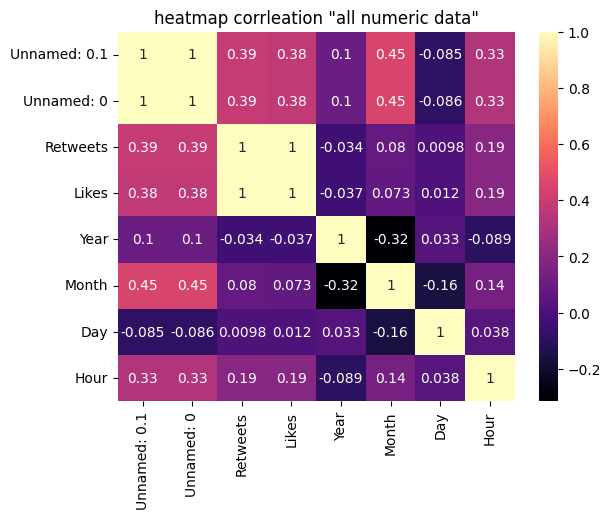

In [ ]:
##Data Visualization: Analysis, Visualization The Correlation Of Numarical Data
numariccol= pd.DataFrame(df)
numariccol= numariccol.select_dtypes(include=['number'])
numariccol.drop(['Unnamed: 0.1','Unnamed: 0'],axis =1)
sas.heatmap(numariccol.corr(), annot=True,cmap='magma' )
plt.title('heatmap corrleation "all numeric data"')
plt.show()

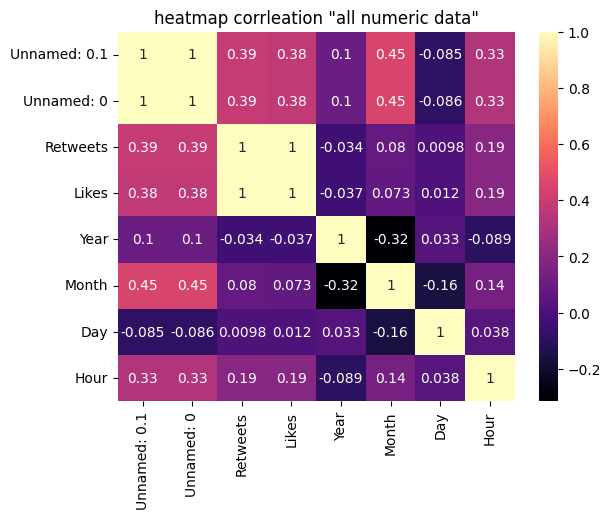

In [ ]:
#Data Visualization: Word clouds, to display the frequently used words

def Wordcloud (Text):
    com_text = ([' '.join (i) for i in Text])
    jointText = ' '. join(com_text).replace('new','Refreshing')
    Cloud =WordCloud(width=600,height=300,background_color='#F3E6F7').generate(C)
    plt.figure(figsize=(10, 5))

    plt.imshow(f,interpolation='bilinear')
    plt.show()

Wordcloud(Text)

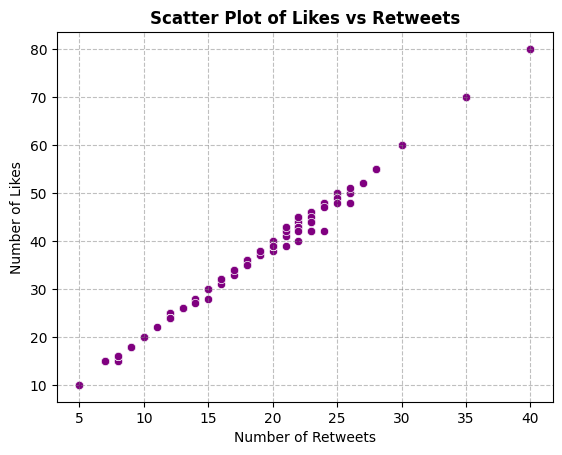

In [ ]:
#Data Visualization: Scatter plot, to show the relationship between sentiment and interactions
plt.figure()

sas.scatterplot(data=df, x='Retweets', y='Likes', color='purple')
plt.title('Scatter Plot of Likes vs Retweets',fontweight='bold')
plt.xlabel('Number of Retweets',fontweight='normal')
plt.ylabel('Number of Likes',fontweight='normal')
plt.grid(True , linestyle='--', color='gray', alpha=0.5)

plt.show()